In [24]:
# imports
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing, model selection
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [25]:
# random_state
SEED = 40

# Load train data
df_train = pd.read_csv('../data/train.csv')
df_train.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


Perhaps, we can drop Time feature since it have near zero MI score.

# Data Preprocessing 

### Builidng undersample

In [26]:
df_train = df_train.sample(frac=1, random_state=SEED) # shuffle dataframe
 # 1st takee all fraud cases
df_fraud = df_train.loc[df_train['IsFraud']==1]
#  2nd take random non fraud cases for the same rows number (they were shuffeled earlier)
df_nonfraud = df_train.loc[df_train['IsFraud']==0].sample(n=len(df_fraud), replace=False, random_state=SEED)
df_balanced_undersample = pd.concat([df_fraud, df_nonfraud]) # concatenate fraud and non fraud parts into one table
df_balanced_undersample = df_balanced_undersample.sample(frac=1, random_state=SEED) # shuffle them again

df_balanced_undersample.head(10)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
11647,11647,13193.0,0.953929,-0.853731,0.889266,-0.629727,-1.226058,-0.124916,-0.845368,0.159949,...,0.091416,0.446475,-0.136626,-0.037544,0.313968,-0.727070,0.050572,0.039373,118.63,1
108570,108570,62863.0,1.315404,-0.033577,-1.157476,-0.557087,2.029931,3.268130,-0.534994,0.808250,...,-0.313307,-1.068934,0.103797,0.992126,0.369398,0.110374,-0.028302,0.011836,5.99,0
5154,5154,1719.0,-3.926970,1.591747,-3.651351,5.717551,3.759827,-2.266875,0.726805,-2.907956,...,2.203823,-0.938597,-1.534221,-0.433038,-0.324845,0.409565,1.251167,-0.926380,0.77,1
53771,53771,47716.0,1.122965,-0.399604,1.089910,0.844644,-0.797722,0.816451,-0.832638,0.403618,...,-0.128957,0.039232,-0.079172,-0.211858,0.445906,0.496436,0.068363,0.005430,4.00,1
91669,91669,58486.0,-0.547002,1.536908,-0.008971,1.099760,1.163819,-0.764134,1.079651,-0.291460,...,0.031196,0.084533,-0.059995,-0.191469,-0.392627,-0.282715,0.065284,0.271826,1.00,1
145616,145616,72980.0,-7.154899,-3.503533,-0.388839,1.845896,1.847447,0.865603,-0.332529,0.459859,...,-1.089856,1.155513,4.347078,-1.084889,0.737983,-0.170080,-0.672669,2.251628,22.00,0
15896,15896,23444.0,-2.843267,3.262912,-3.634127,2.129876,-0.242560,-1.636653,-0.331530,1.973124,...,-0.441349,-1.154959,0.154487,-0.373627,0.069049,-0.704716,-0.007516,-0.068953,89.99,1
7305,7305,5248.0,-1.022959,1.409612,1.503601,0.241218,0.140544,-0.592368,0.624656,-0.826351,...,-0.142736,0.333733,-0.235737,0.360816,0.020860,-0.585824,-0.481738,-0.273936,6.99,0
125393,125393,67702.0,1.130293,-0.090812,1.216001,1.136534,-0.805966,0.275249,-0.709291,0.293914,...,-0.015351,0.056191,-0.004653,-0.005606,0.345278,-0.402289,0.065204,0.026502,4.99,1
140070,140070,71747.0,0.408622,1.011738,0.183321,1.894079,0.331236,-0.667899,0.942603,-0.461909,...,0.223341,0.944361,0.008385,0.580149,-1.119291,-0.260375,0.001614,0.033947,18.28,1


We have balanced undersample now

C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\106595873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_train, palette=colors)
C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\106595873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)


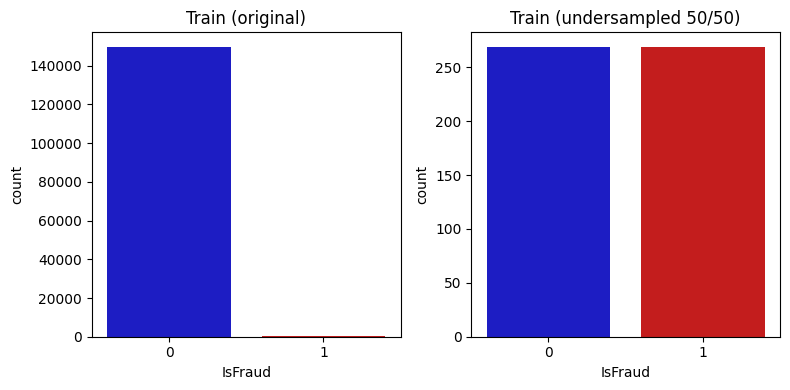

In [27]:
colors = ["#0101DF", "#DF0101"] # Fraud / non Fraud count plot colors

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='IsFraud', data=df_train, palette=colors)
plt.title('Train (original)')

plt.subplot(1,2,2)
sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)
plt.title('Train (undersampled 50/50)')

plt.tight_layout()

Now lets take a look at a correlation matrixes for the undersample and the full dataframe

### Feature Scaling

We saw in 01_eda.ipynb that all features are scaled except for the 'Time' and the 'Transaction_Amount'.
To keep same magnitute for modeling we will perform scalers for both features.
We will use RobustScaler for the 'Transaction_Amount' column as it have outliers and StandardScaler for the 'Time' column.

In [ ]:
# Scaling Time and amount values.
rob_scaler = RobustScaler() # is less prone to outliers
stnd_scaler = StandardScaler()

# df_train['scaled_Transaction_Amount'] = rob_scaler.fit_transform(df_train['Transaction_Amount'].values.reshape(-1,1))
# df_train['scaled_time'] = stnd_scaler.fit_transform(df_train['Time'].values.reshape(-1,1))

# df_train.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

# # we have done it, but now we need to place columns at the first and second placee in our dataframe

# scaled_amount = df_train['scaled_Transaction_Amount']
# scaled_time = df_train['scaled_time']

# df_train.drop(['scaled_Transaction_Amount', 'scaled_time'], axis=1, inplace=True)
# df_train.insert(0, 'scaled_Transaction_Amount', scaled_amount)
# df_train.insert(1, 'scaled_time', scaled_time)

In [ ]:
column_scale = ColumnTransformer(
    transformers= [
        ('robust_scaler', rob_scaler, ['Transaction_Amount']),
        ('stnd_scaler', stnd_scaler, ['Time'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)

# pipeline = Pipeline(steps=[
#     ('preprocessor', column_scale),
#     ('model', model)
# ]
# )

In [37]:
df_train_p = column_scale.fit_transform(df_train)
col = column_scale.get_feature_names_out()
df_train_scaled = pd.DataFrame(
    df_train_p,
    columns = col,
    index = df_train.index
)
df_train_scaled.head(5)

,Transaction_Amount,Time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
135088,0.523802,1.121012,135088.0,-0.757947,-0.392878,2.035651,-2.371615,-1.154433,-0.410098,-0.078361,...,-0.262337,-0.215775,-0.049643,-0.142566,0.033209,0.347895,-0.443559,0.049680,0.082913,0.0
49945,3.215938,-0.184931,49945.0,0.653930,-0.812996,0.466067,1.519816,-0.505959,0.923742,-0.149916,...,0.267906,0.107392,0.097918,-0.339534,-0.244037,0.569257,-0.251625,0.018239,0.043000,0.0
22644,0.040143,-0.887573,22644.0,-0.529005,0.464891,1.953446,1.132813,0.332364,0.596740,0.414819,...,0.078587,0.052718,0.666767,-0.255500,0.194851,0.267723,-0.216928,-0.035005,-0.149917,0.0
14600,-0.194747,-1.553542,14600.0,-0.838504,0.456030,2.721679,-1.942708,-0.316868,-0.311899,0.439705,...,-0.010924,-0.166086,0.208252,-0.344080,0.173927,0.371368,-0.795417,-0.368812,-0.300919,0.0
10753,-0.342039,-2.066898,10753.0,-1.953688,2.531524,0.829018,0.472421,-0.951760,0.953875,-4.262436,...,2.569677,-6.164514,0.569140,1.092969,0.574815,-0.175721,-0.055909,0.050198,0.239833,0.0


In [38]:
df_balanced_undersample = column_scale.fit_transform(df_balanced_undersample)
col = column_scale.get_feature_names_out()
df_balanced_undersample_scaled = pd.DataFrame(
    df_train_p,
    columns = col,
    index = df_train.index
)
df_balanced_undersample_scaled.head(5)

ValueError: Specifying the columns using strings is only supported for dataframes.

All the features are scaled now.

need to scale before plot corr plots

NameError: name 'df_train_scaled' is not defined

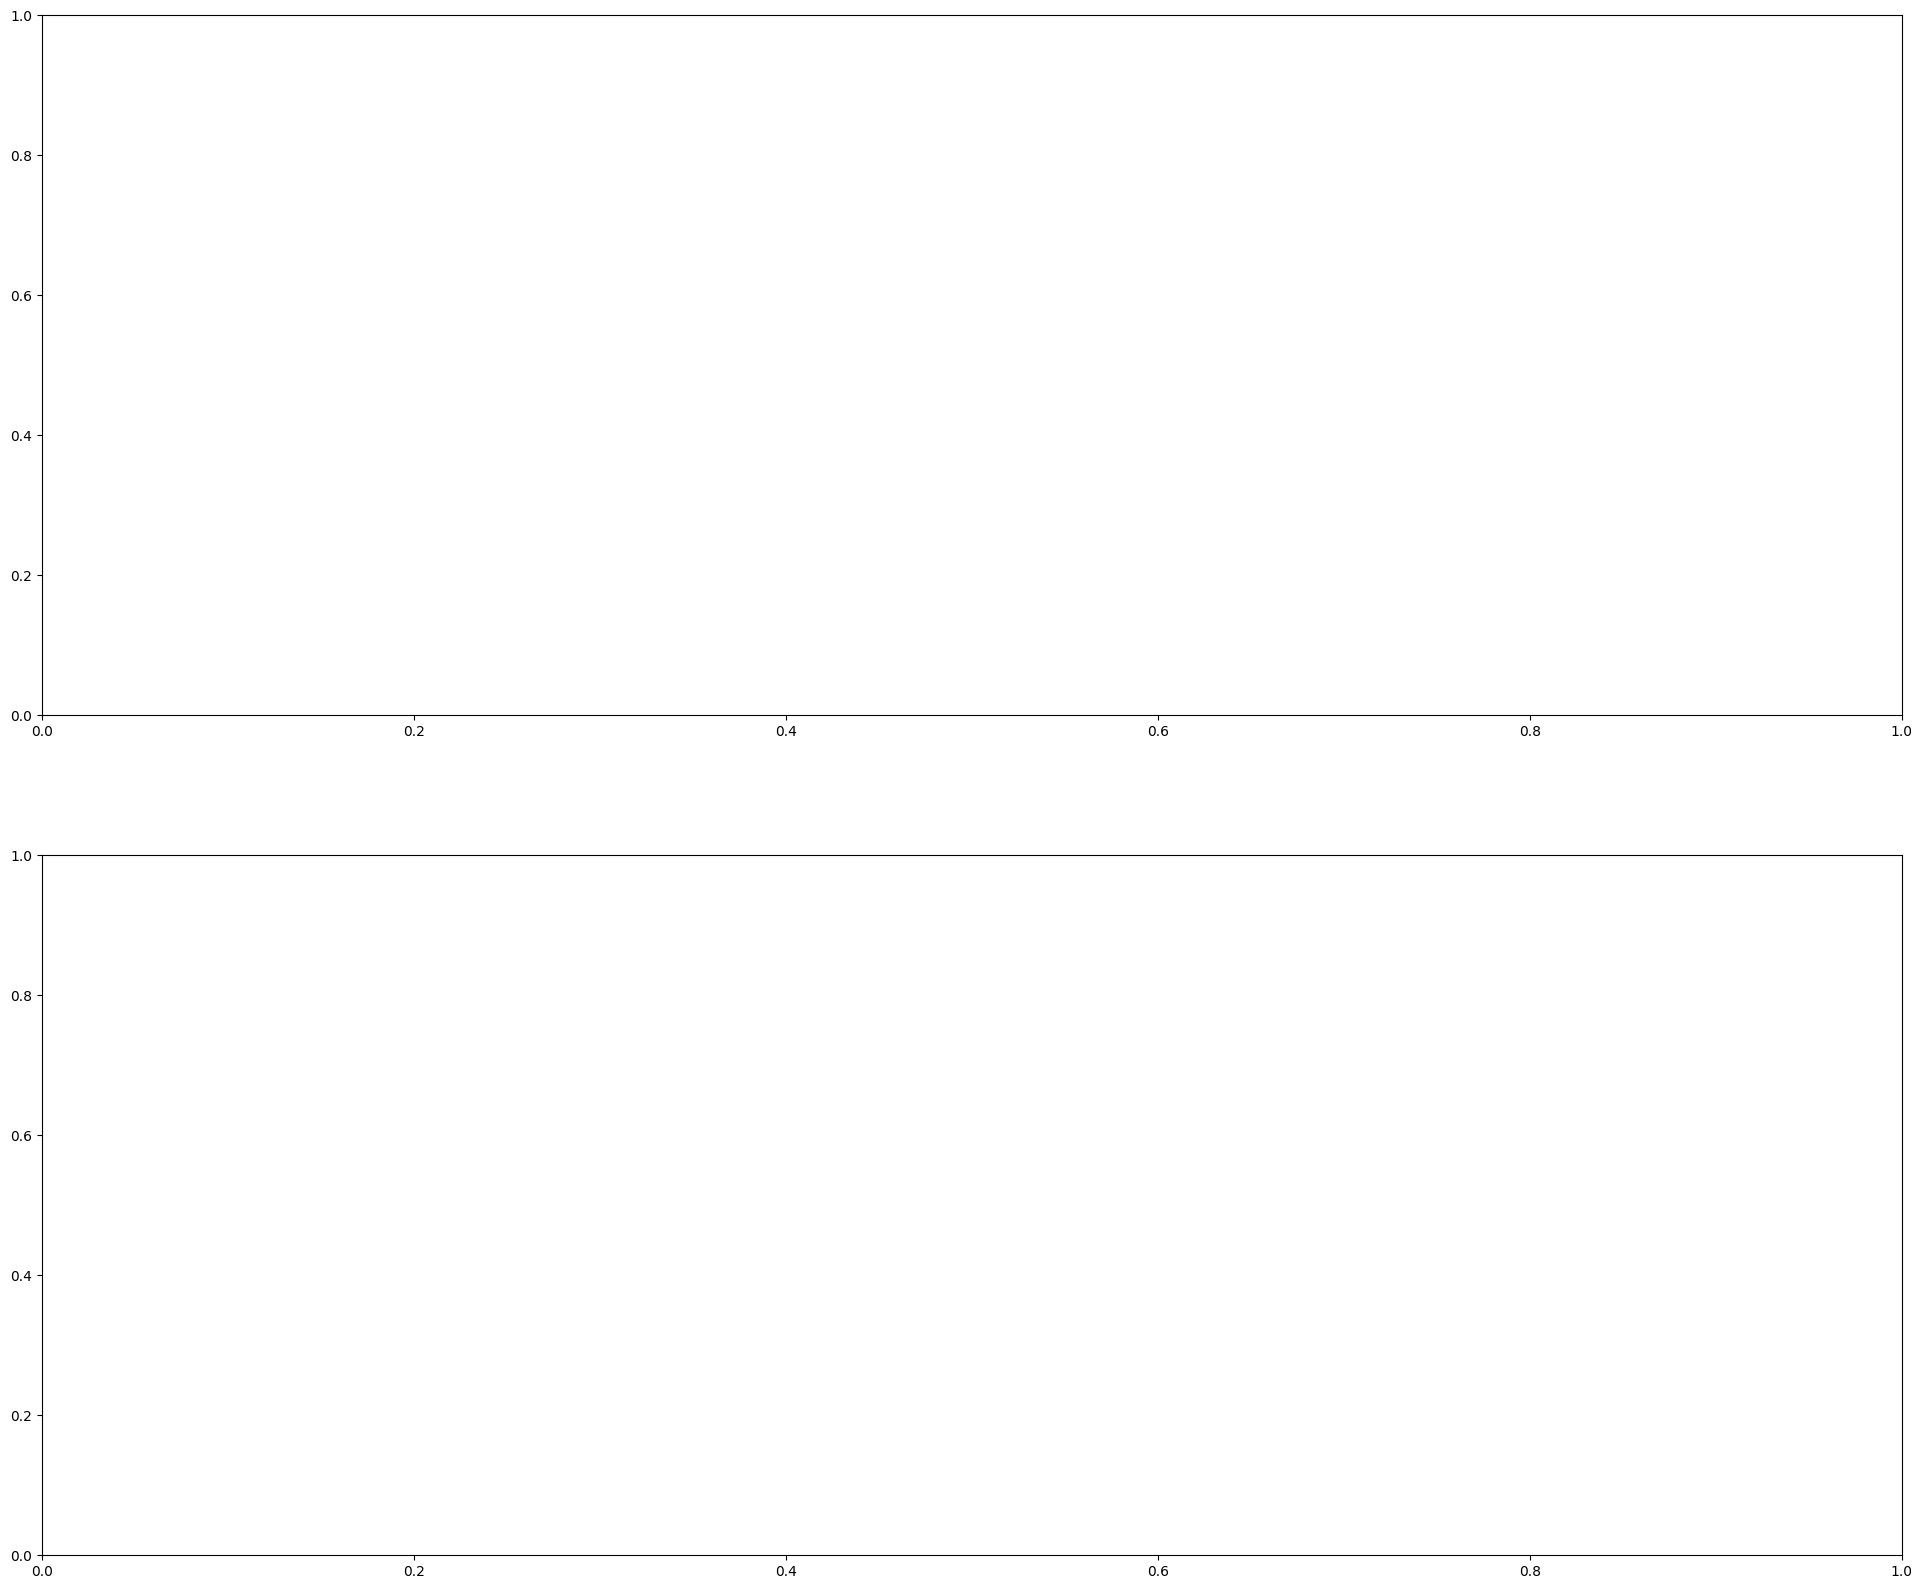

In [36]:
# now lets look at corr matrix for the new and old df (full)
f, (ax1, ax2) = plt.subplots(2,1,figsize=(24,20))

corr = df_train_scaled.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced corr matrix (don't use for reference)", fontsize=14)

sub_sample_corr = df_balanced_undersample_scaled.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample corr matrix (use for reference, because it is balanced)")
plt.show()

We see only few features which negatively correlates with isFraud column: feat1, feat3, feat26


C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\3131961205.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\3131961205.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\3131961205.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_u

Text(0.5, 1.0, 'feat19 vs class negative corr')

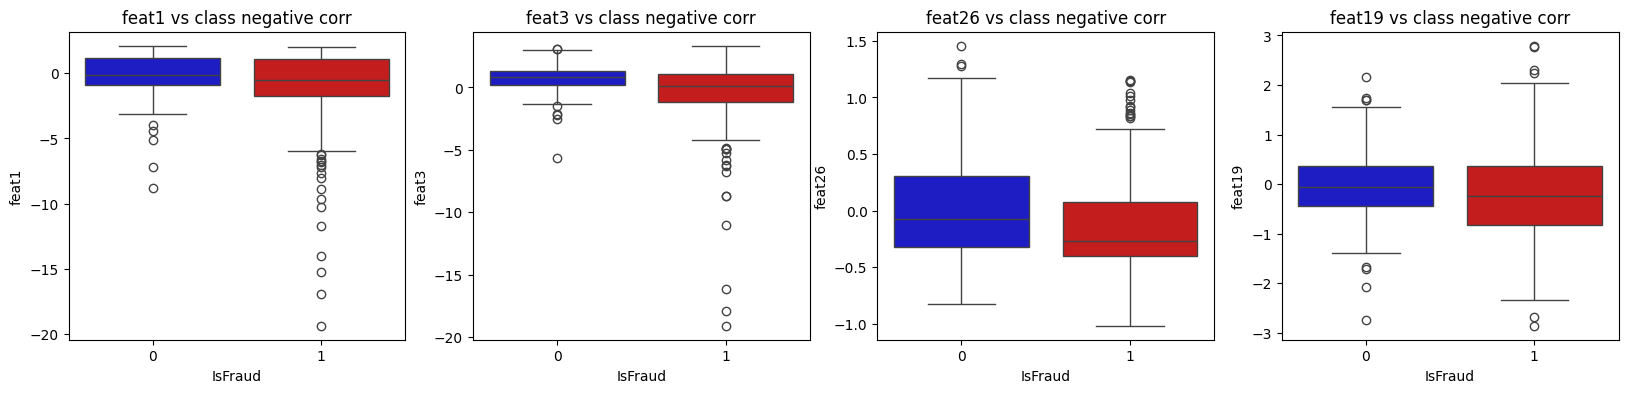

In [30]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat1 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat3 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat26 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat19', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat19 vs class negative corr')




We see only few features which positive correlates with isFraud column: feat4 , feat11, feat18, feat15


C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\349368425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\349368425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_33664\349368425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_und

Text(0.5, 1.0, 'feat15 vs class positive corr')

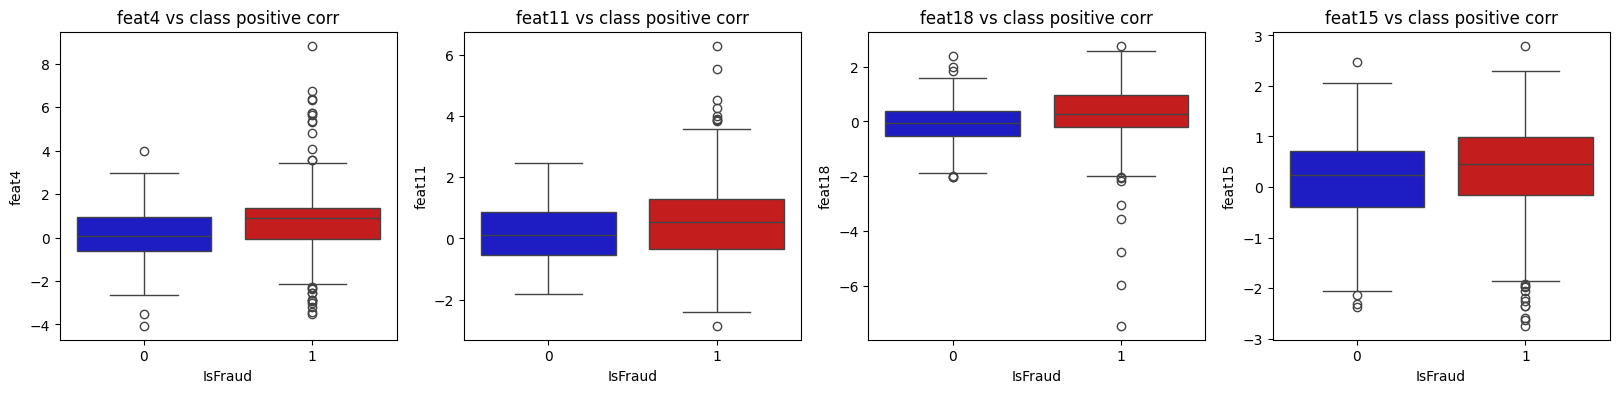

In [ ]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat4 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat11 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat18 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat15', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat15 vs class positive corr')

We see a small differences in the correllated features, nothing outstanding. So, just continue modeling with all the features.

In [ ]:
# Split X and y
# df_balanced_undersample = df_balanced_undersample.copy()
y_balanced_undersample = df_balanced_undersample['IsFraud']
# X_balanced_undersample = df_balanced_undersample.drop(columns=['id'])
X_balanced_undersample = df_balanced_undersample.drop(columns=['IsFraud','id'])

Lets take a look at a feature importance from Mutual Information perspective.

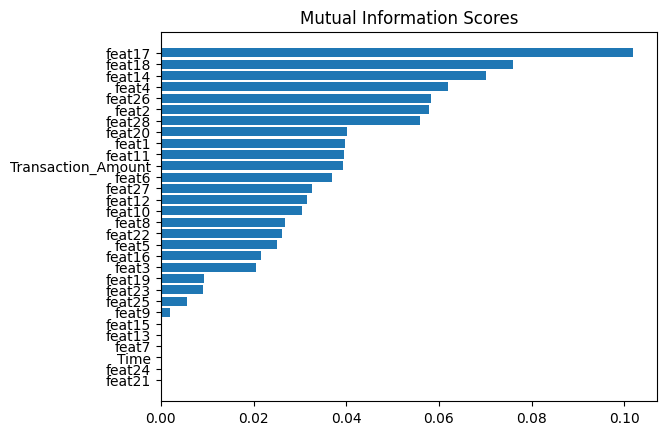

In [ ]:
def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')

mi_scores = make_mi_scores(X_balanced_undersample,y_balanced_undersample)
plot_mi_scores(mi_scores)

That could help us to drop features with low MI score if we will need it in future. But now we just use all of them.

# Model comparison

Here we will test and choose the best classifier for balanced undersample

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced_undersample, y_balanced_undersample, test_size = 0.2, random_state=SEED)

In [ ]:
# Values into arrays for feeding the classification algorithms
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
# Implement simple classifiers
classifiers = {
    "LogisticRegression" : LogisticRegression(random_state=SEED),
    "KNearest" : KNeighborsClassifier(),
    "Support Vector Classifier" : SVC(random_state=SEED),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=SEED),
    "Random Forest" : RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 400, max_depth = 3, learning_rate = 0.01, random_state=SEED
    ),
    "Neural Network" : MLPClassifier(
                                hidden_layer_sizes=(50,50),
                                activation='relu',
                                solver='adam',
                                alpha=1e-3,
                                learning_rate_init=1e-3,
                                early_stopping=True,
                                validation_fraction=0.1,
                                max_iter=500,
                                random_state=SEED
                            )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # shuffled 5 folds for cross_val_score

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=skf)
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "% accuracy score")
print("-------------------------")
for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=skf, scoring='average_precision')
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "average_precision")

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

Classifiers: LogisticRegression Has a training score of 68.0 % accuracy score
Classifiers: KNeighborsClassifier Has a training score of 50.0 % accuracy score
Classifiers: SVC Has a training score of 49.0 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of 60.0 % accuracy score
Classifiers: RandomForestClassifier Has a training score of 65.0 % accuracy score


KeyboardInterrupt: 

We choose the RandomForestClassifier since high level average_precision, accuracy, simplicity and performance. SVC also looks interesting.

In [ ]:
# fit model
model = RandomForestClassifier(n_estimators=400, random_state=SEED)
model.fit(X_train,y_train)

# predictions for validation set
preds = model.predict(X_test)

In [ ]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.66      0.75      0.70        57
           1       0.67      0.57      0.62        51

    accuracy                           0.67       108
   macro avg       0.67      0.66      0.66       108
weighted avg       0.67      0.67      0.66       108



In [ ]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

ROC AUC: 0.7227382180942553


In [ ]:
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

PR AUC 0.7270070673420408


<function matplotlib.pyplot.show(close=None, block=None)>

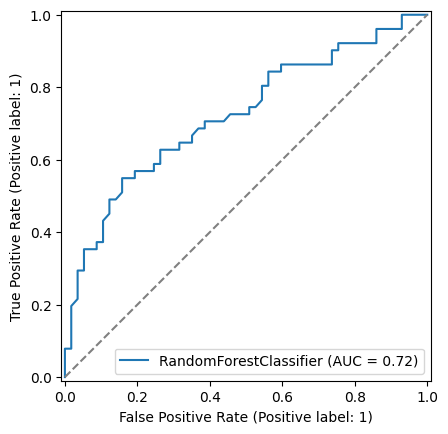

In [ ]:
disp = RocCurveDisplay.from_estimator(
    model, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

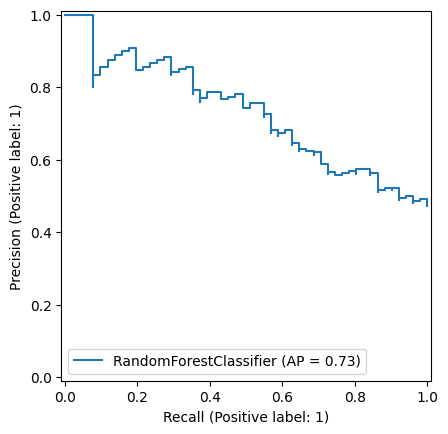

In [ ]:
disp2 = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test,
)
plt.show()

# Submission

In [ ]:
test_df = pd.read_csv('../data/test.csv')
test_ids = test_df['id'].copy()

submission_data = test_df.drop('id', axis=1)


In [ ]:
# Scaling Time and amount values.

submission_data['scaled_Transaction_Amount'] = rob_scaler.transform(submission_data['Transaction_Amount'].values.reshape(-1,1))
submission_data['scaled_time'] = stnd_scaler.transform(submission_data['Time'].values.reshape(-1,1))

submission_data.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

In [ ]:
preds_for_submission = model.predict_proba(submission_data)

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
output = pd.DataFrame(
    {
        'id' : test_ids.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output

,id,IsFraud
0,150000,0.4600
1,150001,0.3450
2,150002,0.6100
3,150003,0.3625
4,150004,0.4700
...,...,...
69124,219124,0.6000
69125,219125,0.6825
69126,219126,0.6425
69127,219127,0.6100


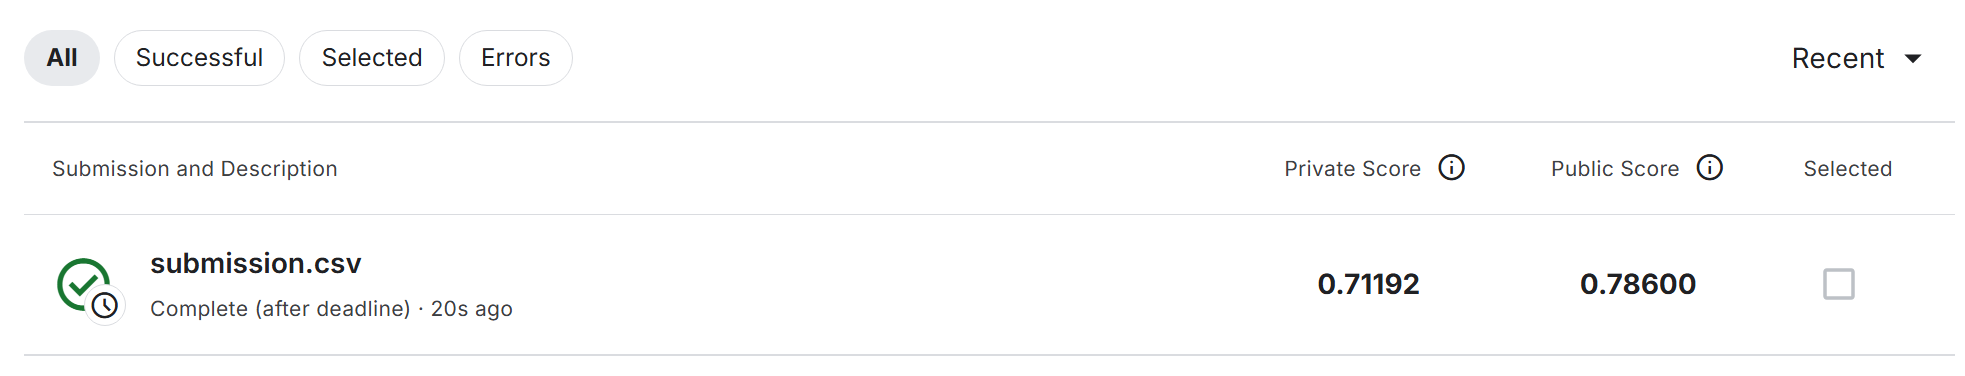

private score 71.1192 public score 0.78600